# 05. Đánh giá & trực quan hóa kết quả mô hình

**Project:** `social-anomaly-clustering`  
**Đề tài:** Ứng dụng kỹ thuật gom nhóm trong phát hiện hành vi bất thường của người dùng mạng xã hội  
**Notebook:** `05_evaluation_visualization.ipynb`

Notebook này tổng hợp kết quả từ hai thuật toán:

- **K-Means Clustering**
- **DBSCAN Clustering**

Mục tiêu là so sánh số lượng người dùng bất thường, tỷ lệ bot trong nhóm bất thường, chất lượng cụm và đưa ra nhận xét cuối cùng cho báo cáo.

> Lưu ý: `bot_label` chỉ được dùng để đánh giá sau khi gom nhóm. Trong quá trình clustering, mô hình không sử dụng nhãn này.

## 1 — Import thư viện và thiết lập đường dẫn

Cell này import các thư viện cần thiết, đồng thời khai báo đường dẫn đến các file kết quả đã tạo ở notebook 03 và 04.

Các file đầu vào chính:

```text
results/csv/kmeans_clustered_users.csv
results/csv/dbscan_clustered_users.csv
datasets/processed/user_features_scaled.csv
```

Các file đầu ra chính:

```text
results/csv/evaluation_summary.csv
results/csv/algorithm_comparison.csv
results/csv/feature_summary_by_anomaly.csv
results/figures/compare_anomaly_users.png
results/figures/compare_bot_ratio_normal_vs_anomaly.png
results/figures/compare_silhouette_score.png
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

RESULT_CSV_DIR = Path("../results/csv")
FIGURE_DIR = Path("../results/figures")
PROCESSED_DIR = Path("../datasets/processed")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_CSV_DIR.mkdir(parents=True, exist_ok=True)

KMEANS_RESULT_PATH = RESULT_CSV_DIR / "kmeans_clustered_users.csv"
DBSCAN_RESULT_PATH = RESULT_CSV_DIR / "dbscan_clustered_users.csv"
SCALED_FEATURES_PATH = PROCESSED_DIR / "user_features_scaled.csv"

EVALUATION_SUMMARY_PATH = RESULT_CSV_DIR / "evaluation_summary.csv"
ALGORITHM_COMPARISON_PATH = RESULT_CSV_DIR / "algorithm_comparison.csv"
FEATURE_SUMMARY_PATH = RESULT_CSV_DIR / "feature_summary_by_anomaly.csv"

print("K-Means result:", KMEANS_RESULT_PATH)
print("DBSCAN result:", DBSCAN_RESULT_PATH)
print("Scaled features:", SCALED_FEATURES_PATH)

K-Means result: ../results/csv/kmeans_clustered_users.csv
DBSCAN result: ../results/csv/dbscan_clustered_users.csv
Scaled features: ../datasets/processed/user_features_scaled.csv


## 2 — Đọc kết quả K-Means và DBSCAN

Cell này đọc hai file kết quả:

```text
kmeans_clustered_users.csv
dbscan_clustered_users.csv
```

Hai file này cần có thông tin cụm, nhãn anomaly và nhãn `bot_label` để phục vụ bước đánh giá.

In [2]:
kmeans_result = pd.read_csv(KMEANS_RESULT_PATH)
dbscan_result = pd.read_csv(DBSCAN_RESULT_PATH)

print("K-Means shape:", kmeans_result.shape)
print("DBSCAN shape:", dbscan_result.shape)

kmeans_result.head()

K-Means shape: (50000, 14)
DBSCAN shape: (50000, 13)


,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label,cluster,anomaly_score,is_anomaly
0,132131,85,1,2353,0,83,5,0,0,1114,1,1,3.164121,0
1,289683,55,5,9617,1,77,14,2,1,186,0,0,3.057194,0
2,779715,6,2,4363,1,61,10,2,1,296,0,0,1.897890,0
3,696168,54,5,2242,1,49,6,4,1,654,1,0,2.395977,0
4,704441,26,3,8438,0,29,6,2,1,1142,1,2,3.228215,0


In [3]:
dbscan_result.head()

,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label,cluster,is_anomaly
0,132131,85,1,2353,0,83,5,0,0,1114,1,2,0
1,289683,55,5,9617,1,77,14,2,1,186,0,0,0
2,779715,6,2,4363,1,61,10,2,1,296,0,0,0
3,696168,54,5,2242,1,49,6,4,1,654,1,0,0
4,704441,26,3,8438,0,29,6,2,1,1142,1,1,0


**Nhận xét:**  

Cả hai thuật toán đều có cùng số dòng là 50,000 người dùng. Số cột có thể khác nhau vì K-Means có thêm `anomaly_score`, còn DBSCAN xác định anomaly trực tiếp bằng `cluster = -1`.

## 3 — Kiểm tra các cột quan trọng

Cell này kiểm tra mỗi file kết quả có đủ các cột cần thiết hay không:

```text
user_id
bot_label
cluster
is_anomaly
```

Nếu thiếu một trong các cột này, các bước đánh giá phía sau có thể bị lỗi.

In [4]:
required_cols = ["user_id", "bot_label", "cluster", "is_anomaly"]

for name, df in [("K-Means", kmeans_result), ("DBSCAN", dbscan_result)]:
    print("\n" + name)

    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        print("Missing columns:", missing_cols)
    else:
        print("All required columns exist.")
        display(df[required_cols].head())


K-Means
All required columns exist.


,user_id,bot_label,cluster,is_anomaly
0,132131,1,1,0
1,289683,0,0,0
2,779715,0,0,0
3,696168,1,0,0
4,704441,1,2,0



DBSCAN
All required columns exist.


,user_id,bot_label,cluster,is_anomaly
0,132131,1,2,0
1,289683,0,0,0
2,779715,0,0,0
3,696168,1,0,0
4,704441,1,1,0


**Nhận xét:**  
Nếu output hiển thị `All required columns exist.` cho cả K-Means và DBSCAN thì dữ liệu đã sẵn sàng để đánh giá.  
Cột `cluster` là nhãn cụm do thuật toán tạo ra, còn `is_anomaly` cho biết người dùng có bị đánh dấu bất thường hay không.

## 4 — So sánh số lượng người dùng bất thường

Cell này tạo bảng so sánh số lượng người dùng bất thường được phát hiện bởi mỗi thuật toán.

- K-Means: anomaly là nhóm top 5% có `anomaly_score` cao nhất.
- DBSCAN: anomaly là các điểm noise có `cluster = -1`.

In [5]:
comparison_summary = pd.DataFrame({
    "algorithm": ["K-Means", "DBSCAN"],
    "total_users": [len(kmeans_result), len(dbscan_result)],
    "anomaly_users": [
        int(kmeans_result["is_anomaly"].sum()),
        int(dbscan_result["is_anomaly"].sum())
    ]
})

comparison_summary["normal_users"] = (
    comparison_summary["total_users"] - comparison_summary["anomaly_users"]
)

comparison_summary["anomaly_ratio"] = (
    comparison_summary["anomaly_users"] / comparison_summary["total_users"] * 100
).round(2)

comparison_summary

,algorithm,total_users,anomaly_users,normal_users,anomaly_ratio
0,K-Means,50000,2500,47500,5.00
1,DBSCAN,50000,2816,47184,5.63


**Nhận xét:**  
Với kết quả hiện tại:

```text
K-Means: 2,500 anomaly users, tương đương 5.00%
DBSCAN: 2,816 anomaly users, tương đương 5.63%
```

Hai tỷ lệ này khá gần nhau. Điều này giúp việc so sánh giữa K-Means và DBSCAN công bằng hơn, vì cả hai đều phát hiện một nhóm nhỏ người dùng có hành vi lệch khỏi phần lớn dữ liệu.

## 5 — Biểu đồ số lượng anomaly theo thuật toán

Cell này vẽ biểu đồ cột so sánh số lượng người dùng bất thường do K-Means và DBSCAN phát hiện.

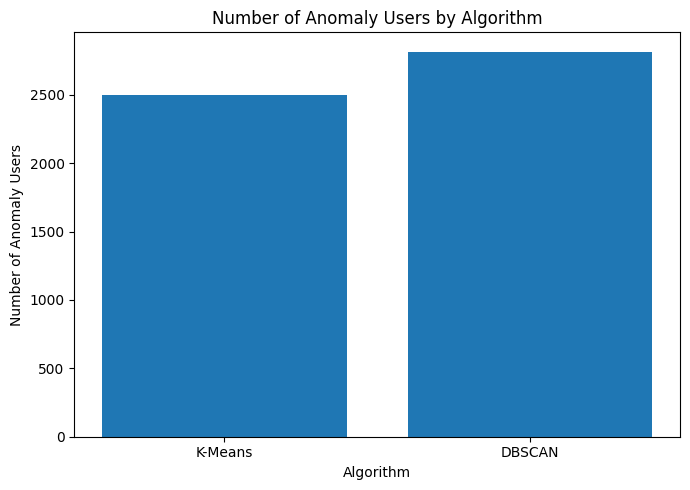

In [6]:
plt.figure(figsize=(7, 5))
plt.bar(comparison_summary["algorithm"], comparison_summary["anomaly_users"])
plt.title("Number of Anomaly Users by Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Number of Anomaly Users")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "compare_anomaly_users.png", dpi=300)
plt.show()

**Nhận xét:**  
Biểu đồ cho thấy DBSCAN phát hiện nhiều anomaly hơn K-Means một chút.  
Sự khác biệt này đến từ cơ chế phát hiện anomaly:

- K-Means dùng ngưỡng top 5% `anomaly_score`.
- DBSCAN tự động xác định noise dựa trên mật độ dữ liệu.

## 6 — Đánh giá tỷ lệ bot trong nhóm Normal và Anomaly

Cell này sử dụng `bot_label` để kiểm tra xem nhóm anomaly có chứa nhiều bot hơn nhóm normal hay không.

Đây là bước đánh giá sau clustering, không phải huấn luyện có giám sát.

In [7]:
def get_anomaly_evaluation(df, algorithm_name):
    normal_df = df[df["is_anomaly"] == 0]
    anomaly_df = df[df["is_anomaly"] == 1]

    result = {
        "algorithm": algorithm_name,
        "normal_users": len(normal_df),
        "anomaly_users": len(anomaly_df),
        "normal_bot_ratio": normal_df["bot_label"].mean() * 100 if len(normal_df) > 0 else np.nan,
        "anomaly_bot_ratio": anomaly_df["bot_label"].mean() * 100 if len(anomaly_df) > 0 else np.nan,
    }

    result["bot_ratio_diff"] = result["anomaly_bot_ratio"] - result["normal_bot_ratio"]

    return result

evaluation_summary = pd.DataFrame([
    get_anomaly_evaluation(kmeans_result, "K-Means"),
    get_anomaly_evaluation(dbscan_result, "DBSCAN")
]).round(2)

evaluation_summary

,algorithm,normal_users,anomaly_users,normal_bot_ratio,anomaly_bot_ratio,bot_ratio_diff
0,K-Means,47500,2500,49.95,51.64,1.69
1,DBSCAN,47184,2816,50.02,50.28,0.26


**Nhận xét:**  
Kết quả hiện tại:

```text
K-Means:
Normal bot ratio  = 49.95%
Anomaly bot ratio = 51.64%
Chênh lệch        = +1.69%

DBSCAN:
Normal bot ratio  = 50.02%
Anomaly bot ratio = 50.28%
Chênh lệch        = +0.26%
```

Nhóm anomaly của K-Means có tỷ lệ bot cao hơn nhóm normal rõ hơn so với DBSCAN. Tuy nhiên, mức chênh lệch vẫn chưa quá lớn, cho thấy các đặc trưng hiện tại chưa đủ mạnh để tách biệt hoàn toàn bot và human.

## 7 — Biểu đồ tỷ lệ bot: Normal vs Anomaly

Cell này trực quan hóa tỷ lệ bot giữa nhóm normal và anomaly của từng thuật toán.

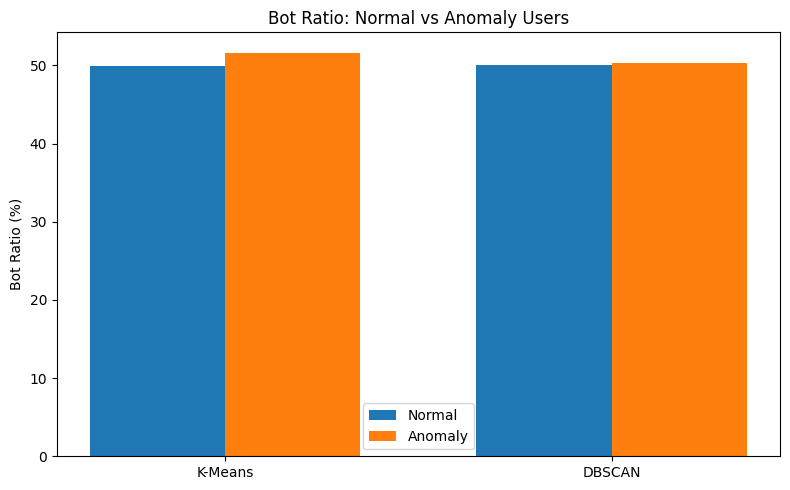

In [8]:
x = np.arange(len(evaluation_summary["algorithm"]))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(
    x - width / 2,
    evaluation_summary["normal_bot_ratio"],
    width,
    label="Normal"
)
plt.bar(
    x + width / 2,
    evaluation_summary["anomaly_bot_ratio"],
    width,
    label="Anomaly"
)

plt.xticks(x, evaluation_summary["algorithm"])
plt.ylabel("Bot Ratio (%)")
plt.title("Bot Ratio: Normal vs Anomaly Users")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "compare_bot_ratio_normal_vs_anomaly.png", dpi=300)
plt.show()

**Nhận xét:**  
Biểu đồ cho thấy nhóm anomaly của K-Means có tỷ lệ bot cao hơn nhóm normal rõ hơn DBSCAN.  
Tuy nhiên, cả hai thuật toán đều chưa tạo ra sự chênh lệch rất lớn giữa normal và anomaly. Điều này phù hợp với bản chất bài toán không giám sát: mô hình phát hiện hành vi lệch cụm, không trực tiếp học để phân loại bot/human.

## 8 — So sánh đặc trưng trung bình giữa Normal và Anomaly

Cell này phân tích nhóm anomaly khác nhóm normal ở các đặc trưng nào.

Các feature được so sánh gồm:

```text
retweet_count
mention_count
follower_count
verified
tweet_length
username_length
hashtag_count
has_hashtag
account_age_days
```

In [9]:
feature_cols = [
    "retweet_count",
    "mention_count",
    "follower_count",
    "verified",
    "tweet_length",
    "username_length",
    "hashtag_count",
    "has_hashtag",
    "account_age_days"
]

def summarize_features_by_anomaly(df, algorithm_name):
    available_features = [col for col in feature_cols if col in df.columns]
    summary = df.groupby("is_anomaly")[available_features].mean().reset_index()
    summary.insert(0, "algorithm", algorithm_name)
    return summary

kmeans_feature_summary = summarize_features_by_anomaly(kmeans_result, "K-Means")
dbscan_feature_summary = summarize_features_by_anomaly(dbscan_result, "DBSCAN")

feature_summary = pd.concat(
    [kmeans_feature_summary, dbscan_feature_summary],
    ignore_index=True
)

feature_summary = feature_summary.round(2)
feature_summary

,algorithm,is_anomaly,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days
0,K-Means,0,49.94,2.51,4990.60,0.50,62.43,9.69,2.50,0.83,624.12
1,K-Means,1,51.20,2.53,4950.64,0.50,66.30,11.92,2.45,0.82,613.19
2,DBSCAN,0,49.96,2.51,4992.97,0.50,62.23,9.60,2.54,0.85,624.59
3,DBSCAN,1,50.76,2.53,4915.41,0.49,69.21,13.14,1.84,0.62,606.49


**Nhận xét:**  

Với kết quả hiện tại:

**K-Means anomaly** có xu hướng:

```text
tweet_length cao hơn normal
username_length cao hơn normal
retweet_count nhỉnh hơn normal
```

Điều này cho thấy K-Means đang đánh dấu những tài khoản có mẫu nội dung/tên tài khoản lệch hơn so với cụm chính.

**DBSCAN anomaly** có xu hướng:

```text
tweet_length cao hơn normal
username_length cao hơn normal
hashtag_count thấp hơn normal
has_hashtag thấp hơn normal
```

Điều này cho thấy DBSCAN phát hiện anomaly dựa trên cấu trúc mật độ tổng thể, không chỉ dựa vào việc dùng nhiều hashtag.

## 9 — Lưu bảng feature summary

Cell này lưu bảng so sánh đặc trưng giữa normal và anomaly để dùng trong báo cáo.

In [10]:
feature_summary.to_csv(FEATURE_SUMMARY_PATH, index=False)

print("Saved feature summary to:", FEATURE_SUMMARY_PATH)

Saved feature summary to: ../results/csv/feature_summary_by_anomaly.csv


**Nhận xét:**  
File `feature_summary_by_anomaly.csv` giúp bạn trích số liệu nhanh khi viết báo cáo hoặc làm slide. Đây là bảng rất hữu ích để giải thích “vì sao nhóm anomaly khác nhóm normal”.

## 10 — So sánh số cụm và số anomaly/noise

Cell này tổng hợp:

- K-Means tạo ra bao nhiêu cụm.
- DBSCAN tạo ra bao nhiêu cụm chính.
- Mỗi thuật toán phát hiện bao nhiêu anomaly/noise.

In [11]:
def get_cluster_info(df, algorithm_name):
    clusters = sorted(df["cluster"].unique())

    if algorithm_name == "DBSCAN":
        n_clusters = len([c for c in clusters if c != -1])
        n_noise = int((df["cluster"] == -1).sum())
    else:
        n_clusters = len(clusters)
        n_noise = int(df["is_anomaly"].sum())

    return {
        "algorithm": algorithm_name,
        "n_clusters": n_clusters,
        "anomaly_or_noise_users": n_noise,
        "anomaly_or_noise_ratio": n_noise / len(df) * 100
    }

cluster_info = pd.DataFrame([
    get_cluster_info(kmeans_result, "K-Means"),
    get_cluster_info(dbscan_result, "DBSCAN")
]).round(2)

cluster_info

,algorithm,n_clusters,anomaly_or_noise_users,anomaly_or_noise_ratio
0,K-Means,3,2500,5.00
1,DBSCAN,4,2816,5.63


**Nhận xét:**  
Kết quả hiện tại:

```text
K-Means: 3 cụm, 2,500 anomaly users, tỷ lệ 5.00%
DBSCAN: 4 cụm, 2,816 noise/anomaly users, tỷ lệ 5.63%
```

K-Means cần chọn trước số cụm `k`, còn DBSCAN tự tạo số cụm dựa trên mật độ dữ liệu. Đây là điểm khác biệt quan trọng khi so sánh hai thuật toán.

## 11 — Tính Silhouette Score

Cell này tính Silhouette Score cho kết quả cuối cùng của K-Means và DBSCAN.

Silhouette Score càng cao thì cụm càng tách biệt tốt. Tuy nhiên, với dữ liệu hành vi mạng xã hội, các cụm thường có sự chồng lấn nên điểm số có thể không cao.

In [12]:
df_scaled = pd.read_csv(SCALED_FEATURES_PATH)

def safe_silhouette_score(X, labels, algorithm_name):
    unique_labels = set(labels)

    if algorithm_name == "DBSCAN":
        valid_clusters = [label for label in unique_labels if label != -1]
        if len(valid_clusters) < 2:
            return np.nan
    else:
        if len(unique_labels) < 2:
            return np.nan

    return silhouette_score(X, labels)

kmeans_silhouette = safe_silhouette_score(
    df_scaled,
    kmeans_result["cluster"],
    "K-Means"
)

dbscan_silhouette = safe_silhouette_score(
    df_scaled,
    dbscan_result["cluster"],
    "DBSCAN"
)

silhouette_comparison = pd.DataFrame({
    "algorithm": ["K-Means", "DBSCAN"],
    "silhouette_score": [kmeans_silhouette, dbscan_silhouette]
}).round(6)

silhouette_comparison

,algorithm,silhouette_score
0,K-Means,0.151312
1,DBSCAN,0.123253


**Nhận xét:**  
Kết quả hiện tại:

```text
K-Means silhouette = 0.151312
DBSCAN silhouette  = 0.123253
```

K-Means có Silhouette Score cao hơn, cho thấy cụm của K-Means tách biệt tốt hơn DBSCAN trong cấu hình hiện tại.  
Tuy nhiên, cả hai điểm số đều chưa cao, nghĩa là cấu trúc hành vi trong dataset chưa tách thành các cụm thật sự rõ ràng.

## 12 — Biểu đồ so sánh Silhouette Score

Cell này vẽ biểu đồ so sánh chất lượng cụm giữa K-Means và DBSCAN.

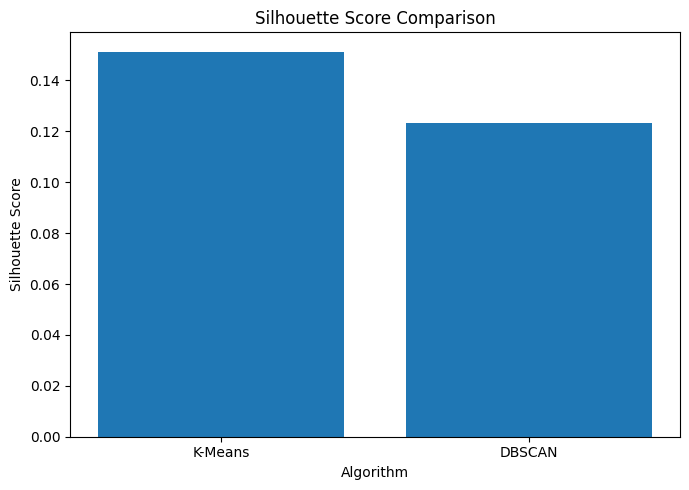

In [13]:
plt.figure(figsize=(7, 5))
plt.bar(silhouette_comparison["algorithm"], silhouette_comparison["silhouette_score"])
plt.title("Silhouette Score Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "compare_silhouette_score.png", dpi=300)
plt.show()

**Nhận xét:**  
Biểu đồ xác nhận K-Means có Silhouette Score cao hơn DBSCAN.  
Do đó, nếu xét riêng tiêu chí độ tách cụm, K-Means tốt hơn trong thực nghiệm này.  
Tuy nhiên, DBSCAN vẫn có ưu điểm riêng là phát hiện noise/anomaly trực tiếp thông qua nhãn `-1`.

## 13 — So sánh định tính K-Means và DBSCAN

| Tiêu chí | K-Means | DBSCAN |
|---|---|---|
| Cơ chế gom nhóm | Dựa trên khoảng cách đến tâm cụm | Dựa trên mật độ điểm dữ liệu |
| Có cần chọn số cụm không? | Có, cần chọn `k` | Không cần chọn số cụm |
| Tham số quan trọng | `n_clusters` | `eps`, `min_samples` |
| Cách phát hiện anomaly | Điểm xa tâm cụm nhất | Điểm bị gán nhãn `-1` |
| Ưu điểm | Dễ hiểu, dễ triển khai, chạy nhanh | Phát hiện noise trực tiếp |
| Nhược điểm | Phải chọn `k`, nhạy với thang đo | Nhạy với `eps`, `min_samples` |
| Phù hợp với đề tài | Tốt để phân tích nhóm hành vi | Tốt để phát hiện điểm bất thường |

**Nhận xét:**  
K-Means phù hợp để giải thích nhóm hành vi người dùng vì cơ chế đơn giản, dễ trình bày. DBSCAN phù hợp hơn với ý tưởng phát hiện bất thường vì có khái niệm noise rõ ràng. Trong project này, cả hai thuật toán được dùng để bổ sung góc nhìn cho nhau.

## 14 — Bảng tổng hợp cuối cùng

Cell này tạo bảng tổng hợp gọn, tránh lỗi merge sinh ra các cột trùng như:

```text
anomaly_users_x
anomaly_users_y
normal_users_x
normal_users_y
```

In [14]:
final_summary = pd.DataFrame({
    "algorithm": comparison_summary["algorithm"],
    "total_users": comparison_summary["total_users"],
    "n_clusters": cluster_info["n_clusters"],
    "anomaly_users": comparison_summary["anomaly_users"],
    "anomaly_ratio": comparison_summary["anomaly_ratio"],
    "normal_bot_ratio": evaluation_summary["normal_bot_ratio"],
    "anomaly_bot_ratio": evaluation_summary["anomaly_bot_ratio"],
    "bot_ratio_diff": evaluation_summary["bot_ratio_diff"],
    "silhouette_score": silhouette_comparison["silhouette_score"]
})

final_summary = final_summary.round(3)
final_summary

,algorithm,total_users,n_clusters,anomaly_users,anomaly_ratio,normal_bot_ratio,anomaly_bot_ratio,bot_ratio_diff,silhouette_score
0,K-Means,50000,3,2500,5.00,49.95,51.64,1.69,0.151
1,DBSCAN,50000,4,2816,5.63,50.02,50.28,0.26,0.123


**Nhận xét:**  
Bảng tổng hợp cuối cùng cho thấy:

```text
K-Means:
- 3 cụm
- 2,500 anomaly users
- anomaly ratio 5.00%
- anomaly bot ratio 51.64%
- silhouette score 0.151

DBSCAN:
- 4 cụm
- 2,816 anomaly users
- anomaly ratio 5.63%
- anomaly bot ratio 50.28%
- silhouette score 0.123
```

Nhìn chung, K-Means có kết quả tốt hơn về Silhouette Score và tỷ lệ bot trong nhóm anomaly. DBSCAN có ưu điểm là phát hiện anomaly trực tiếp bằng noise.

## 15 — Lưu các bảng đánh giá cuối cùng

Cell này lưu các bảng phục vụ báo cáo.

In [15]:
final_summary.to_csv(EVALUATION_SUMMARY_PATH, index=False)
comparison_summary.to_csv(ALGORITHM_COMPARISON_PATH, index=False)

print("Saved evaluation summary to:", EVALUATION_SUMMARY_PATH)
print("Saved algorithm comparison to:", ALGORITHM_COMPARISON_PATH)

Saved evaluation summary to: ../results/csv/evaluation_summary.csv
Saved algorithm comparison to: ../results/csv/algorithm_comparison.csv


## 16 — Nhận xét tổng hợp cho báo cáo

```text
Kết quả thực nghiệm cho thấy cả K-Means và DBSCAN đều có thể phát hiện một nhóm người dùng có hành vi lệch khỏi phần lớn dữ liệu. K-Means phát hiện 2,500 người dùng bất thường, tương đương 5.00% tổng dữ liệu, trong khi DBSCAN phát hiện 2,816 người dùng bất thường, tương đương 5.63%.

K-Means đạt Silhouette Score là 0.151, cao hơn DBSCAN với 0.123, cho thấy cụm của K-Means có độ tách biệt tốt hơn trong thực nghiệm này. Ngoài ra, nhóm anomaly của K-Means có tỷ lệ bot là 51.64%, cao hơn nhóm normal là 49.95%. DBSCAN cũng có tỷ lệ bot trong nhóm anomaly cao hơn nhóm normal, nhưng mức chênh lệch chỉ khoảng 0.26%.

Tuy nhiên, tỷ lệ bot giữa nhóm normal và anomaly của cả hai thuật toán không chênh lệch quá lớn. Điều này cho thấy các đặc trưng hiện tại như retweet_count, mention_count, follower_count, tweet_length, username_length và hashtag_count chưa đủ mạnh để phân biệt rõ bot và human.

Dù vậy, kết quả vẫn phù hợp với mục tiêu của đề tài là ứng dụng kỹ thuật gom nhóm để phát hiện các hành vi bất thường theo hướng không giám sát.
```

## 17 — Kết luận cuối cùng

Qua toàn bộ pipeline, project đã hoàn thành các bước:

1. Khám phá dữ liệu ban đầu.
2. Tiền xử lý dữ liệu và tạo đặc trưng hành vi.
3. Chuẩn hóa dữ liệu.
4. Áp dụng K-Means để gom nhóm và tính anomaly score.
5. Áp dụng DBSCAN để phát hiện noise/anomaly.
6. So sánh kết quả giữa hai thuật toán.
7. Trực quan hóa và lưu các bảng kết quả phục vụ báo cáo.

Các file đầu ra quan trọng của notebook này:

```text
results/csv/evaluation_summary.csv
results/csv/algorithm_comparison.csv
results/csv/feature_summary_by_anomaly.csv
results/figures/compare_anomaly_users.png
results/figures/compare_bot_ratio_normal_vs_anomaly.png
results/figures/compare_silhouette_score.png
```